# Payload-shift experiment — analysis

Interactive version of `analyze.py`. Reads `results/manifest*.csv` and the
per-run `results/runs/*.npz` written by `run_experiment.py`.

The robot carries a payload that shifts rearward + laterally at T/2. Falls are
attributed to phase 2 iff they happen after the shift; because the mismatch is
*persistent*, the phase-2 efficiency metrics (velocity tracking, tip deviation,
actuator power) discriminate even when nothing falls — no-adapt can lose by
**limping**, not only by falling.

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Config ───────────────────────────────────────────────────────────────────
TRIGGER = "cusum"      # "ce" | "dt" | "cusum"  (which manifest to load)
TRACE_SEED = 0          # seed shown in the trace figure

HERE = os.path.abspath("")          # experiment-payload-adapt/
RESULTS_DIR = os.path.join(HERE, "results")
RUNS_DIR = os.path.join(RESULTS_DIR, "runs")

METHODS = [("noadapt", "tab:gray"), ("grid", "tab:green"),
           ("bo", "tab:blue"), ("marxefe", "tab:orange"),
           ("marxefe_sysid", "tab:purple"), ("oracle", "tab:red")]
LABEL = {"noadapt": "No-adapt (hold flat)", "grid": "Grid (windowed)",
         "bo": "BO (windowed)", "marxefe": "MARX-EFE",
         "marxefe_sysid": "MARX-EFE (sysid)", "oracle": "Oracle (per-phase)"}
COLOR = dict(METHODS)
DT = 0.01

## Load the manifest

In [2]:
suffix = "" if TRIGGER == "ce" else f"_{TRIGGER}"
manifest_path = os.path.join(RESULTS_DIR, f"manifest{suffix}.csv")
df = pd.read_csv(manifest_path)
arms = [m for m, _ in METHODS if m in set(df["method"])]
df["method"] = pd.Categorical(df["method"], categories=arms, ordered=True)
print(f"{len(df)} runs, arms: {arms}")
df.head()

30 runs, arms: ['noadapt', 'marxefe', 'oracle']


,seed,method,trigger,triggered,fell,fall_phase,dist,t_end,trigger_t,fall_t,...,mean_tip_ph1,mean_tip_ph2,mean_vx_ph1,mean_vx_ph2,power_ph1,power_ph2,cot_ph1,cot_ph2,baseline_ce,npz
0,0,marxefe,cusum,1,0,0,13.898847,29.99,17.03,NaN,...,0.645986,3.143407,0.565724,0.382443,97.392567,97.851507,0.588467,0.874584,0.227556,runs/pl_seed0_marxefe_cusum.npz
1,0,noadapt,cusum,1,0,0,13.936854,29.99,17.03,NaN,...,0.645986,3.159269,0.565724,0.384977,97.392567,98.164464,0.588467,0.871606,0.227556,runs/pl_seed0_noadapt_cusum.npz
2,0,oracle,cusum,0,0,0,15.913812,29.99,NaN,NaN,...,0.504190,2.836341,0.548913,0.528834,94.177296,138.016650,0.586467,0.892098,0.227556,runs/pl_seed0_oracle_cusum.npz
3,1,marxefe,cusum,1,0,0,14.075396,29.99,18.26,NaN,...,0.660916,3.196076,0.568077,0.388233,98.231111,97.533026,0.591075,0.858736,0.227556,runs/pl_seed1_marxefe_cusum.npz
4,1,noadapt,cusum,1,0,0,13.983888,29.99,18.26,NaN,...,0.660916,3.217819,0.568077,0.382133,98.231111,97.451555,0.591075,0.871716,0.227556,runs/pl_seed1_noadapt_cusum.npz


## Per-arm summary + significance vs no-adapt

Fall proportions per arm are tested against `noadapt` (Fisher exact, two-sided).

In [3]:
from scipy.stats import fisher_exact

na = df[df["method"] == "noadapt"]
n0, f0 = len(na), int(na["fell"].sum())

rows = []
for m in arms:
    g = df[df["method"] == m]
    n, f = len(g), int(g["fell"].sum())
    f2 = int((g["fall_phase"] == 2).sum())
    p = (fisher_exact([[f, n - f], [f0, n0 - f0]])[1]
         if (m != "noadapt" and n0) else np.nan)
    rows.append(dict(
        arm=m, n=n, falls=f, fall_rate=f / max(n, 1), falls_ph2=f2,
        p_vs_noadapt=p, dist=g["dist"].mean(),
        vx_ph1=g["mean_vx_ph1"].mean(), vx_ph2=g["mean_vx_ph2"].mean(),
        tip_ph2=g["mean_tip_ph2"].mean(), power_ph2=g["power_ph2"].mean(),
        cot_ph2=g["cot_ph2"].mean(), det_latency=g["det_latency"].mean(),
        n_triggers=g["n_triggers"].mean()))

summary = pd.DataFrame(rows).set_index("arm")
summary.round(3)

,n,falls,fall_rate,falls_ph2,p_vs_noadapt,dist,vx_ph1,vx_ph2,tip_ph2,power_ph2,cot_ph2,det_latency,n_triggers
arm,,,,,,,,,,,,,
noadapt,10,0,0.0,0,NaN,13.778,0.563,0.371,3.350,97.411,0.898,1.879,8.1
marxefe,10,0,0.0,0,1.0,13.828,0.563,0.375,3.282,97.684,0.894,1.879,8.2
oracle,10,0,0.0,0,1.0,15.766,0.545,0.526,2.848,139.337,0.906,2.167,3.7


## Summary figure — bars with per-seed scatter

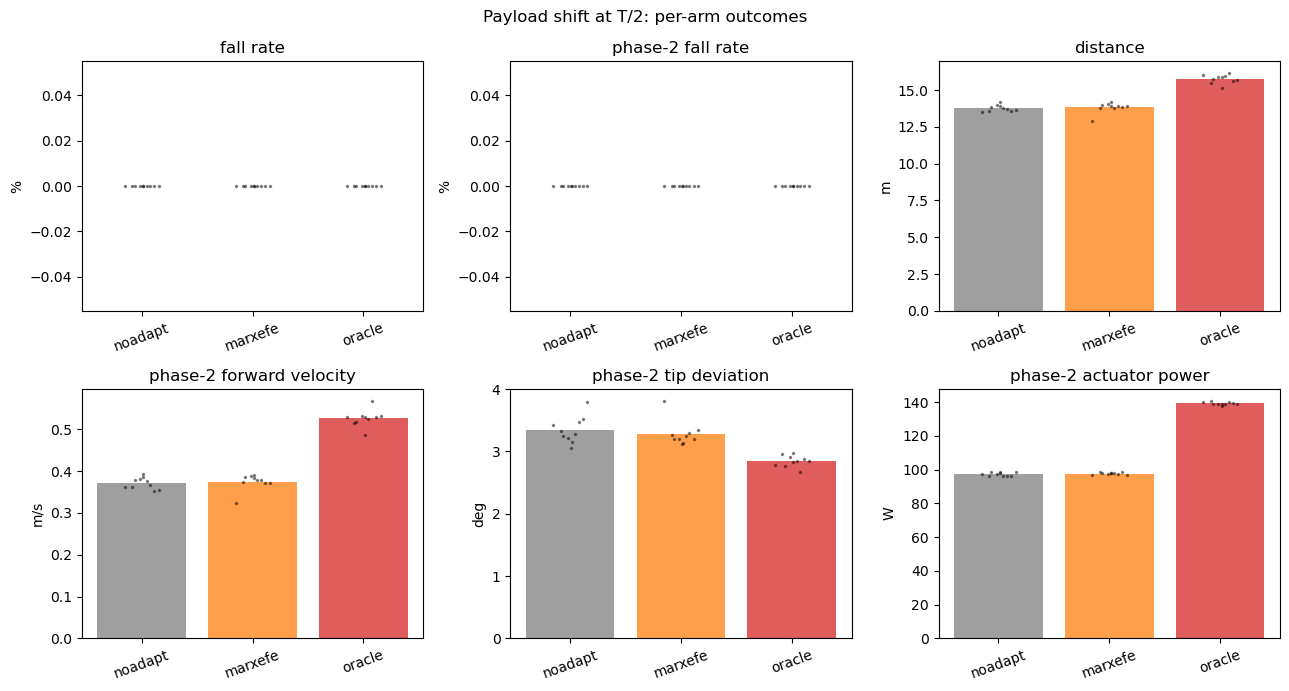

In [4]:
panels = [("fall rate", lambda g: 100.0 * g["fell"], "%"),
          ("phase-2 fall rate", lambda g: 100.0 * (g["fall_phase"] == 2), "%"),
          ("distance", lambda g: g["dist"], "m"),
          ("phase-2 forward velocity", lambda g: g["mean_vx_ph2"], "m/s"),
          ("phase-2 tip deviation", lambda g: g["mean_tip_ph2"], "deg"),
          ("phase-2 actuator power", lambda g: g["power_ph2"], "W")]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (title, fn, unit) in zip(axes.ravel(), panels):
    for i, m in enumerate(arms):
        vals = np.asarray(fn(df[df["method"] == m]), float)
        ax.bar(i, np.nanmean(vals), color=COLOR[m], alpha=0.75)
        jitter = 0.12 * np.random.default_rng(0).standard_normal(len(vals))
        ax.plot(i + jitter, vals, ".", color="k", ms=3, alpha=0.4)
    ax.set_xticks(range(len(arms)))
    ax.set_xticklabels(arms, rotation=20)
    ax.set_title(title)
    ax.set_ylabel(unit)
fig.suptitle("Payload shift at T/2: per-arm outcomes")
fig.tight_layout()
plt.show()

## Traces for one seed

vx / tip deviation / trigger statistic vs time, all arms overlaid. Dashed
vertical line: payload shift; thin vertical lines: trigger fires; ×: fall.

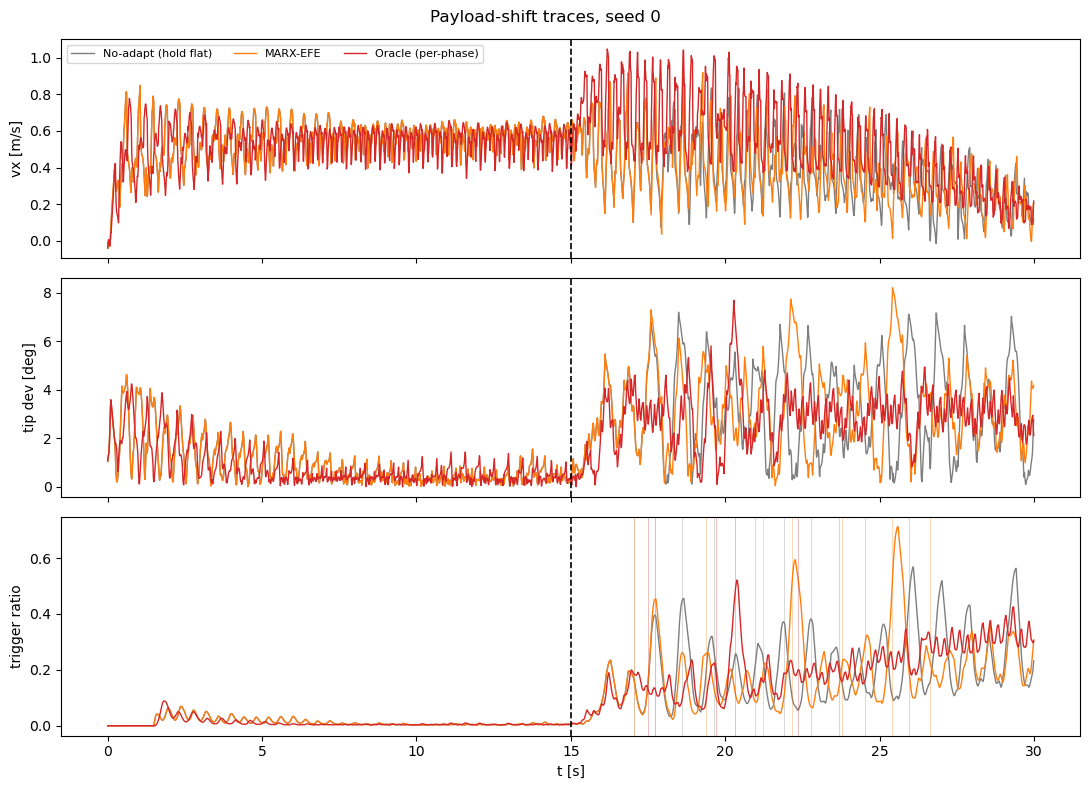

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
t_shift = None
for m, c in METHODS:
    f = os.path.join(RUNS_DIR, f"pl_seed{TRACE_SEED}_{m}{suffix}.npz")
    if not os.path.exists(f):
        continue
    d = np.load(f, allow_pickle=True)
    t = d["t"]
    t_shift = float(d["t_shift"])
    tip = np.rad2deg(np.sqrt(np.asarray(d["roll"]) ** 2
                             + np.asarray(d["pitch"]) ** 2))
    axes[0].plot(t, d["vx"], color=c, lw=1, label=LABEL[m])
    axes[1].plot(t, tip, color=c, lw=1)
    axes[2].plot(t, d["ratio"], color=c, lw=1)
    for fs in d["fire_steps"]:
        axes[2].axvline(fs * DT, color=c, lw=0.6, alpha=0.35)
    if int(d["fell"]):
        axes[0].plot(t[-1], d["vx"][-1], "x", color=c, ms=9, mew=2)
for ax in axes:
    if t_shift is not None and t_shift >= 0:
        ax.axvline(t_shift, color="k", ls="--", lw=1.2)
axes[0].set_ylabel("vx [m/s]")
axes[0].legend(fontsize=8, ncol=3)
axes[1].set_ylabel("tip dev [deg]")
axes[2].set_ylabel("trigger ratio")
axes[2].set_xlabel("t [s]")
fig.suptitle(f"Payload-shift traces, seed {TRACE_SEED}")
fig.tight_layout()
plt.show()

## Extra: per-run parameter movement

How far did each adaptive arm actually move from the incumbent, relative to the
parameter box? (Diagnoses incumbent-pinning: MARX-EFE can trigger and "adapt"
every window while barely moving.)

In [6]:
import sys

sys.path.insert(0, os.path.dirname(HERE))
from methods.cpg_bounds import bounds_lower, bounds_upper

rng_box = bounds_upper.numpy() - bounds_lower.numpy()
rows = []
for m in arms:
    for _, r in df[df["method"] == m].iterrows():
        d = np.load(os.path.join(RESULTS_DIR, r["npz"]), allow_pickle=True)
        sel = d["selected_params"]
        if len(sel) == 0:
            continue
        dev = np.abs(sel - d["incumbent"]) / rng_box
        rows.append(dict(arm=m, seed=int(r["seed"]),
                         n_proposals=len(sel),
                         mean_dev=float(dev.mean()),
                         max_dev=float(dev.max())))
move = pd.DataFrame(rows)
(move.groupby("arm", observed=True)[["n_proposals", "mean_dev", "max_dev"]]
 .mean().round(4)) if len(move) else print("no adaptive runs with proposals")

,n_proposals,mean_dev,max_dev
arm,,,
marxefe,9.3,0.0041,0.0312
noadapt,9.3,0.0000,0.0000
